In [3]:
import numpy as np
import pandas as pd
import pickle
import shap
import os
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

True

In [4]:
# Load model artifacts from Phase 5 & 7
with open("../models/xgboost_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("../models/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

with open("../models/feature_names.pkl", "rb") as f:
    feature_names = pickle.load(f)

with open("../models/threshold.pkl", "rb") as f:
    threshold = pickle.load(f)

with open("../models/shap_explainer.pkl", "rb") as f:
    explainer = pickle.load(f)

print(f"Model: XGBoost")
print(f"Features: {len(feature_names)}")
print(f"Threshold: {threshold}")
print(f"SHAP base value: {explainer.expected_value:.4f}")

Model: XGBoost
Features: 44
Threshold: 0.4
SHAP base value: -0.0006


In [5]:
# Load featured data and pick sample customers
df = pd.read_csv("../data/featured_data/featured_data.csv")
X = df.drop(columns=["Target"])
y = df["Target"]

# Sample and predict
np.random.seed(42)
sample_idx = np.random.choice(len(X), size=1000, replace=False)
X_sample = X.iloc[sample_idx]
y_sample = y.iloc[sample_idx]

X_sample_scaled = scaler.transform(X_sample)
probas = model.predict_proba(X_sample_scaled)[:, 1]

# Find one high-risk and one low-risk customer
high_risk_idx = np.where(probas > 0.7)[0][0]
low_risk_idx = np.where(probas < 0.15)[0][0]

print(f"HIGH RISK customer: index={high_risk_idx}, probability={probas[high_risk_idx]:.2%}, actual={'Default' if y_sample.iloc[high_risk_idx]==1 else 'Fully Paid'}")
print(f"LOW RISK customer:  index={low_risk_idx}, probability={probas[low_risk_idx]:.2%}, actual={'Default' if y_sample.iloc[low_risk_idx]==1 else 'Fully Paid'}")

HIGH RISK customer: index=1, probability=78.07%, actual=Fully Paid
LOW RISK customer:  index=5, probability=10.12%, actual=Fully Paid


In [6]:
# Human-readable feature names for the LLM prompt
FEATURE_DISPLAY = {
    "loan_amnt": "Loan Amount",
    "funded_amnt": "Funded Amount",
    "funded_amnt_inv": "Investor Funded Amount",
    "int_rate": "Interest Rate",
    "installment": "Monthly Installment",
    "annual_inc": "Annual Income",
    "dti": "Debt-to-Income Ratio",
    "delinq_2yrs": "Delinquencies (last 2 years)",
    "fico_range_low": "FICO Score (low)",
    "fico_range_high": "FICO Score (high)",
    "inq_last_6mths": "Credit Inquiries (last 6 months)",
    "open_acc": "Open Credit Accounts",
    "total_acc": "Total Credit Accounts",
    "pub_rec": "Public Records (bankruptcies etc.)",
    "revol_bal": "Revolving Balance",
    "revol_util": "Revolving Utilization %",
    "initial_list_status": "Listing Status",
    "application_type": "Application Type",
    "term_in_months": "Loan Term (months)",
    "emp_length_num": "Employment Length (years)",
    "subgrade_num": "Loan Sub-Grade (higher=riskier)",
    "credit_history_months": "Credit History Length (months)",
    "home_ownership_OTHER": "Home Ownership: Other",
    "home_ownership_OWN": "Home Ownership: Own",
    "home_ownership_RENT": "Home Ownership: Rent",
    "verification_status_Source Verified": "Income: Source Verified",
    "verification_status_Verified": "Income: Verified",
    "purpose_credit_card": "Purpose: Credit Card",
    "purpose_debt_consolidation": "Purpose: Debt Consolidation",
    "purpose_educational": "Purpose: Education",
    "purpose_home_improvement": "Purpose: Home Improvement",
    "purpose_house": "Purpose: House Purchase",
    "purpose_major_purchase": "Purpose: Major Purchase",
    "purpose_medical": "Purpose: Medical",
    "purpose_moving": "Purpose: Moving",
    "purpose_other": "Purpose: Other",
    "purpose_renewable_energy": "Purpose: Renewable Energy",
    "purpose_small_business": "Purpose: Small Business",
    "purpose_vacation": "Purpose: Vacation",
    "purpose_wedding": "Purpose: Wedding",
    "fico_avg": "FICO Score (average)",
    "loan_to_income": "Loan-to-Income Ratio",
    "installment_to_income": "Installment-to-Income Ratio",
    "credit_per_account": "Credit Balance per Account",
}

def get_display_name(feat):
    return FEATURE_DISPLAY.get(feat, feat.replace("_", " ").title())

In [7]:
def get_shap_explanation(customer_idx, X_scaled):
    """Get SHAP values and extract risk/protective factors for a customer."""
    shap_values = explainer.shap_values(X_scaled[customer_idx].reshape(1, -1))[0]
    
    # Pair feature names with SHAP values, sort by absolute impact
    impacts = sorted(
        zip(feature_names, shap_values),
        key=lambda x: abs(x[1]),
        reverse=True
    )
    
    risk_factors = [(f, v) for f, v in impacts if v > 0][:5]
    protective_factors = [(f, v) for f, v in impacts if v < 0][:5]
    
    return {
        "shap_values": shap_values,
        "risk_factors": risk_factors,
        "protective_factors": protective_factors,
    }

# Generate SHAP for both customers
high_risk_shap = get_shap_explanation(high_risk_idx, X_sample_scaled)
low_risk_shap = get_shap_explanation(low_risk_idx, X_sample_scaled)

print("=" * 60)
print("HIGH RISK CUSTOMER - SHAP Analysis")
print("=" * 60)
print(f"Default Probability: {probas[high_risk_idx]:.2%}")
print(f"\nTop Risk Factors:")
for feat, val in high_risk_shap["risk_factors"]:
    print(f"  ↑ {get_display_name(feat)}: {val:+.3f}")
print(f"\nProtective Factors:")
for feat, val in high_risk_shap["protective_factors"]:
    print(f"  ↓ {get_display_name(feat)}: {val:+.3f}")

print(f"\n{'=' * 60}")
print("LOW RISK CUSTOMER - SHAP Analysis")
print("=" * 60)
print(f"Default Probability: {probas[low_risk_idx]:.2%}")
print(f"\nTop Risk Factors:")
for feat, val in low_risk_shap["risk_factors"]:
    print(f"  ↑ {get_display_name(feat)}: {val:+.3f}")
print(f"\nProtective Factors:")
for feat, val in low_risk_shap["protective_factors"]:
    print(f"  ↓ {get_display_name(feat)}: {val:+.3f}")

HIGH RISK CUSTOMER - SHAP Analysis
Default Probability: 78.07%

Top Risk Factors:
  ↑ Loan Sub-Grade (higher=riskier): +0.737
  ↑ Loan Term (months): +0.215
  ↑ FICO Score (low): +0.188
  ↑ Debt-to-Income Ratio: +0.117
  ↑ Credit History Length (months): +0.083

Protective Factors:
  ↓ Home Ownership: Rent: -0.133
  ↓ Loan-to-Income Ratio: -0.054
  ↓ Total Credit Accounts: -0.034
  ↓ Annual Income: -0.015
  ↓ Income: Verified: -0.013

LOW RISK CUSTOMER - SHAP Analysis
Default Probability: 10.12%

Top Risk Factors:
  ↑ Total Credit Accounts: +0.064
  ↑ Interest Rate: +0.035
  ↑ Purpose: Credit Card: +0.006
  ↑ Monthly Installment: +0.004
  ↑ Installment-to-Income Ratio: +0.002

Protective Factors:
  ↓ Loan Sub-Grade (higher=riskier): -1.230
  ↓ FICO Score (low): -0.272
  ↓ Debt-to-Income Ratio: -0.158
  ↓ Loan Term (months): -0.102
  ↓ Home Ownership: Rent: -0.093


In [8]:
# OpenRouter client (OpenAI-compatible API)
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
)

print("OpenRouter client initialized ✓")

OpenRouter client initialized ✓


In [9]:
SYSTEM_PROMPT = """You are a senior credit risk analyst at a bank. Your job is to write clear, 
professional explanations of loan decisions for loan officers and applicants.

Rules:
- Write in plain English. No technical jargon (no SHAP, ML, model, algorithm, etc.)
- Be professional, objective, and empathetic
- Structure: 2-3 short paragraphs
- If rejected: suggest specific improvements the applicant can make
- If approved: note any areas to monitor
- Reference the specific factors by name"""


def build_explanation_prompt(probability, shap_result, raw_features, feat_names):
    """Build the user prompt with prediction + SHAP context."""
    
    # Determine decision
    decision = "REJECTED" if probability >= threshold else "APPROVED"
    
    if probability < 0.3:
        risk_level = "Low Risk"
    elif probability < 0.5:
        risk_level = "Medium Risk"
    elif probability < 0.7:
        risk_level = "High Risk"
    else:
        risk_level = "Very High Risk"
    
    # Format risk factors
    risk_lines = []
    for feat, shap_val in shap_result["risk_factors"]:
        feat_idx = feat_names.index(feat)
        actual_val = raw_features[feat_idx]
        risk_lines.append(f"  - {get_display_name(feat)} (value: {actual_val:.2f})")
    
    # Format protective factors
    prot_lines = []
    for feat, shap_val in shap_result["protective_factors"]:
        feat_idx = feat_names.index(feat)
        actual_val = raw_features[feat_idx]
        prot_lines.append(f"  - {get_display_name(feat)} (value: {actual_val:.2f})")
    
    prompt = f"""Loan Application Assessment:

- Default Probability: {probability:.1%}
- Risk Level: {risk_level}
- Decision: {decision}

Key factors INCREASING risk:
{chr(10).join(risk_lines) if risk_lines else "  None significant"}

Key factors DECREASING risk (positive indicators):
{chr(10).join(prot_lines) if prot_lines else "  None significant"}

Write a clear explanation of this loan decision."""
    
    return prompt

# Test the prompt with the high-risk customer
test_prompt = build_explanation_prompt(
    probas[high_risk_idx],
    high_risk_shap,
    X_sample.iloc[high_risk_idx].values,
    feature_names
)

print("PROMPT PREVIEW:")
print("=" * 60)
print(f"SYSTEM: {SYSTEM_PROMPT[:100]}...")
print("=" * 60)
print(test_prompt)

PROMPT PREVIEW:
SYSTEM: You are a senior credit risk analyst at a bank. Your job is to write clear, 
professional explanatio...
Loan Application Assessment:

- Default Probability: 78.1%
- Risk Level: Very High Risk
- Decision: REJECTED

Key factors INCREASING risk:
  - Loan Sub-Grade (higher=riskier) (value: 25.00)
  - Loan Term (months) (value: 60.00)
  - FICO Score (low) (value: 660.00)
  - Debt-to-Income Ratio (value: 25.27)
  - Credit History Length (months) (value: 160.00)

Key factors DECREASING risk (positive indicators):
  - Home Ownership: Rent (value: 0.00)
  - Loan-to-Income Ratio (value: 0.16)
  - Total Credit Accounts (value: 29.00)
  - Annual Income (value: 80000.00)
  - Income: Verified (value: 0.00)

Write a clear explanation of this loan decision.


In [10]:
def generate_explanation(probability, shap_result, raw_features, feat_names):
    """Call OpenRouter LLM to generate a human-readable loan explanation."""
    
    user_prompt = build_explanation_prompt(probability, shap_result, raw_features, feat_names)
    
    response = client.chat.completions.create(
        model="openai/gpt-4o-mini",  # Fast + cheap on OpenRouter
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt},
        ],
        temperature=0.3,
        max_tokens=500,
    )
    
    return response.choices[0].message.content.strip()

print("generate_explanation() ready")

generate_explanation() ready


### Test 1: HIGH RISK Customer Explanation

In [11]:
# HIGH RISK — LLM Explanation
high_risk_explanation = generate_explanation(
    probas[high_risk_idx],
    high_risk_shap,
    X_sample.iloc[high_risk_idx].values,
    feature_names
)

print("=" * 60)
print(f"CUSTOMER: HIGH RISK | Probability: {probas[high_risk_idx]:.2%}")
print("=" * 60)
print()
print(high_risk_explanation)

CUSTOMER: HIGH RISK | Probability: 78.07%

Thank you for your loan application. After a thorough assessment, we regret to inform you that your application has been rejected due to a very high risk level, with a default probability of 78.1%. Several factors contributed to this decision, including a high loan sub-grade and a loan term of 60 months, which indicate a greater risk associated with the loan. Additionally, your FICO score of 660 is considered low, and your debt-to-income ratio of 25.27% suggests that a significant portion of your income is already committed to existing debts.

While there are positive indicators, such as your annual income of $80,000 and a good number of total credit accounts, the high-risk factors outweigh these benefits at this time. To improve your chances for future applications, we recommend focusing on increasing your credit score, reducing your debt-to-income ratio, and possibly considering a shorter loan term. These changes could enhance your overall c

### Test 2: LOW RISK Customer Explanation

In [12]:
# LOW RISK — LLM Explanation
low_risk_explanation = generate_explanation(
    probas[low_risk_idx],
    low_risk_shap,
    X_sample.iloc[low_risk_idx].values,
    feature_names
)

print("=" * 60)
print(f"CUSTOMER: LOW RISK | Probability: {probas[low_risk_idx]:.2%}")
print("=" * 60)
print()
print(low_risk_explanation)

CUSTOMER: LOW RISK | Probability: 10.12%

We are pleased to inform you that your loan application has been approved. Your overall risk level is classified as low, with a default probability of 10.1%. This indicates a strong likelihood that you will be able to meet your repayment obligations. Your FICO Score of 750 is a significant positive factor, demonstrating your creditworthiness and responsible credit management.

While your application has been approved, there are a few areas to monitor moving forward. The total number of credit accounts you hold is 11, which can sometimes indicate a higher risk if not managed carefully. Additionally, your interest rate of 6.92% is something to keep in mind, as it may affect your overall repayment costs. We recommend staying on top of your monthly installment of $370.09 and ensuring that your installment-to-income ratio remains manageable. Overall, we believe you are in a good position, and we encourage you to maintain your current financial habit

## 7. Full Pipeline Function

In [13]:
def explain_loan_decision(raw_features, feature_names=feature_names):
    """
    FULL PIPELINE: Raw features → Prediction → SHAP → LLM Explanation
    
    Args:
        raw_features: 1D array of 44 feature values (matching feature_names order)
        feature_names: list of feature names
    
    Returns:
        dict with probability, decision, risk_factors, protective_factors, llm_explanation
    """
    # Step 1: Scale and predict
    scaled = scaler.transform([raw_features])
    proba = model.predict_proba(scaled)[0, 1]
    decision = "REJECTED" if proba >= threshold else "APPROVED"
    
    # Step 2: SHAP explanation
    shap_vals = explainer.shap_values(scaled)[0]
    impacts = sorted(zip(feature_names, shap_vals), key=lambda x: abs(x[1]), reverse=True)
    risk_factors = [(f, v) for f, v in impacts if v > 0][:5]
    protective_factors = [(f, v) for f, v in impacts if v < 0][:5]
    
    shap_result = {
        "shap_values": shap_vals,
        "risk_factors": risk_factors,
        "protective_factors": protective_factors,
    }
    
    # Step 3: LLM explanation
    llm_explanation = generate_explanation(proba, shap_result, raw_features, feature_names)
    
    return {
        "probability": proba,
        "decision": decision,
        "risk_factors": [(get_display_name(f), v) for f, v in risk_factors],
        "protective_factors": [(get_display_name(f), v) for f, v in protective_factors],
        "llm_explanation": llm_explanation,
    }

print("explain_loan_decision() ready — full pipeline function")

explain_loan_decision() ready — full pipeline function


### Test: Run Full Pipeline on a Random Customer

In [14]:
# Pick a random customer and run the full pipeline
random_customer = X_sample.iloc[42].values
result = explain_loan_decision(random_customer)

print("=" * 60)
print("FULL PIPELINE RESULT")
print("=" * 60)
print(f"\nDefault Probability: {result['probability']:.2%}")
print(f"Decision: {result['decision']}")
print(f"\nTop Risk Factors:")
for feat, val in result["risk_factors"]:
    print(f"  ↑ {feat}")
print(f"\nProtective Factors:")
for feat, val in result["protective_factors"]:
    print(f"  ↓ {feat}")
print(f"\n{'=' * 60}")
print("LLM EXPLANATION")
print("=" * 60)
print(result["llm_explanation"])

d:\AI Credit Risk Scoring + Explainable AI + LLM Layer\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


FULL PIPELINE RESULT

Default Probability: 33.11%
Decision: APPROVED

Top Risk Factors:
  ↑ Loan-to-Income Ratio
  ↑ Annual Income
  ↑ Total Credit Accounts
  ↑ Employment Length (years)
  ↑ FICO Score (low)

Protective Factors:
  ↓ Loan Sub-Grade (higher=riskier)
  ↓ Debt-to-Income Ratio
  ↓ Credit Balance per Account
  ↓ Loan Term (months)
  ↓ Home Ownership: Rent

LLM EXPLANATION
We are pleased to inform you that your loan application has been approved. Your overall risk level is categorized as medium risk, and while there are some factors that increase your risk, there are also several positive indicators that contributed to this decision.

It is important to note that your Loan-to-Income Ratio is at 0.32, which indicates a significant portion of your income is allocated to debt repayment. Additionally, your FICO Score of 675 is on the lower side, and you have recently started your employment, which may impact your financial stability. We recommend focusing on improving your credit

## 8. Side-by-Side: SHAP Plot + LLM Explanation

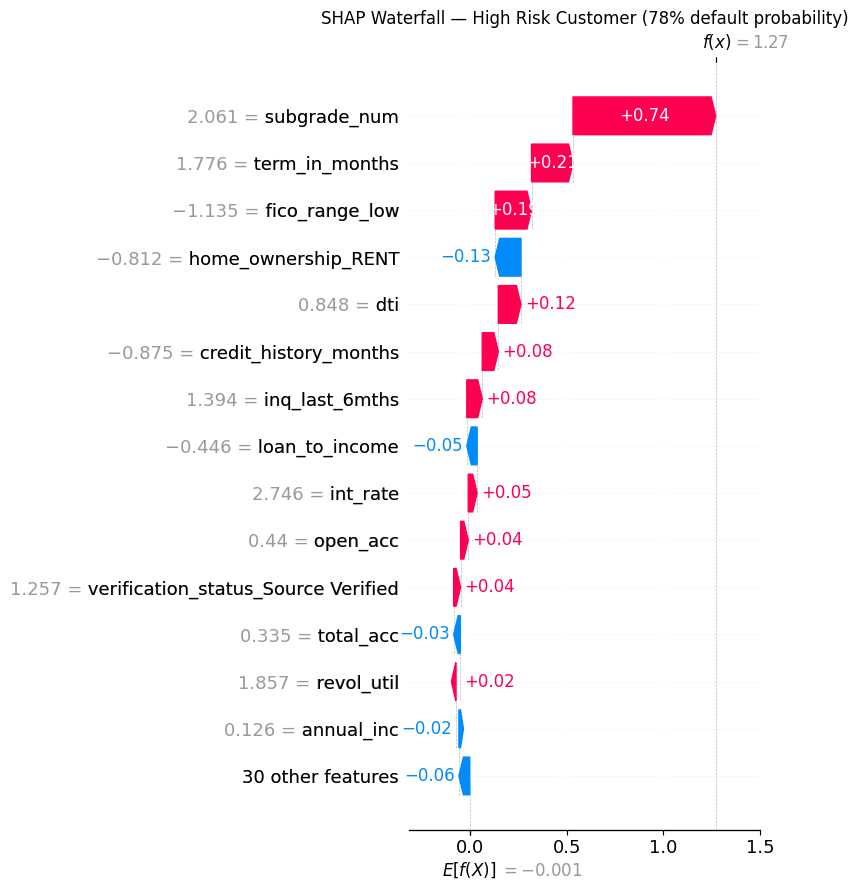


LLM EXPLANATION (Same Customer)
Thank you for your loan application. After a thorough assessment, we regret to inform you that your application has been rejected due to a very high risk level, with a default probability of 78.1%. Several factors contributed to this decision, including a high loan sub-grade and a loan term of 60 months, which indicate a greater risk associated with the loan. Additionally, your FICO score of 660 is considered low, and your debt-to-income ratio of 25.27% suggests that a significant portion of your income is already committed to existing debts.

While there are positive indicators, such as your annual income of $80,000 and a good number of total credit accounts, the high-risk factors outweigh these benefits at this time. To improve your chances for future applications, we recommend focusing on increasing your credit score, reducing your debt-to-income ratio, and possibly considering a shorter loan term. These changes could enhance your overall credit prof

In [15]:
import matplotlib.pyplot as plt

# SHAP waterfall for the high-risk customer
shap_vals_hr = high_risk_shap["shap_values"]

plt.figure(figsize=(10, 8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_vals_hr,
        base_values=explainer.expected_value,
        data=X_sample_scaled[high_risk_idx],
        feature_names=feature_names,
    ),
    max_display=15,
    show=False,
)
plt.title(f"SHAP Waterfall — High Risk Customer ({probas[high_risk_idx]:.0%} default probability)", fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("LLM EXPLANATION (Same Customer)")
print("=" * 60)
print(high_risk_explanation)

## 9. Batch Explanations — Multiple Customers

Generate explanations for several customers at once to demonstrate scalability.

In [16]:
# Batch: explain 5 random customers
batch_indices = [0, 10, 50, 100, 200]

for i, idx in enumerate(batch_indices):
    raw = X_sample.iloc[idx].values
    result = explain_loan_decision(raw)
    
    print(f"\n{'#' * 60}")
    print(f"CUSTOMER {i+1} | Prob: {result['probability']:.2%} | Decision: {result['decision']}")
    print('#' * 60)
    print(result["llm_explanation"])
    print()

d:\AI Credit Risk Scoring + Explainable AI + LLM Layer\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



############################################################
CUSTOMER 1 | Prob: 68.67% | Decision: REJECTED
############################################################
Thank you for your loan application. After a thorough review, we regret to inform you that your application has been denied due to a high risk assessment. The primary factors contributing to this decision include a high loan sub-grade, a longer loan term of 60 months, and a debt-to-income ratio of 23.66%. Additionally, your FICO score of 675 is considered low, which raises concerns about your overall creditworthiness.

To improve your chances of approval in the future, we recommend focusing on a few key areas. First, consider working on increasing your FICO score by making timely payments and reducing any outstanding debts. Additionally, if possible, aim to lower your debt-to-income ratio by either increasing your income or paying down existing debts. Lastly, consider exploring options for a shorter loan term, as this 

d:\AI Credit Risk Scoring + Explainable AI + LLM Layer\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



############################################################
CUSTOMER 2 | Prob: 44.80% | Decision: REJECTED
############################################################
Thank you for your loan application. After a thorough review, we regret to inform you that your application has been rejected. The primary reason for this decision is the elevated default probability of 44.8%, which places your application in the medium risk category. Several factors contributed to this assessment, including a low FICO score of 680, a high number of open credit accounts (28), and a lack of employment history, as you indicated no years of employment.

To improve your chances for future applications, we recommend focusing on a few key areas. First, consider working on increasing your FICO score, as a higher score can significantly enhance your creditworthiness. Additionally, reducing the number of open credit accounts and managing your credit balances more effectively can also help lower your risk profil

d:\AI Credit Risk Scoring + Explainable AI + LLM Layer\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



############################################################
CUSTOMER 3 | Prob: 25.91% | Decision: APPROVED
############################################################
Your loan application has been approved, and we appreciate your patience throughout this process. The overall assessment indicates a low risk level, with a default probability of 25.9%. This means that while there are some factors that could increase risk, your application demonstrates sufficient strength to move forward.

Several positive indicators contributed to this decision, including your FICO score of 710, which reflects a good credit history, and the absence of recent credit inquiries. Additionally, the loan term of 36 months is favorable. However, we recommend monitoring your debt-to-income ratio, which is currently at 22.36, as well as the number of open credit accounts, which stands at 14. Keeping these factors in check will help maintain your financial health and ensure that you remain on track with your lo

d:\AI Credit Risk Scoring + Explainable AI + LLM Layer\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



############################################################
CUSTOMER 4 | Prob: 57.16% | Decision: REJECTED
############################################################
Thank you for your loan application. After a thorough review, we regret to inform you that your application has been rejected due to a high risk assessment. The primary factors contributing to this decision include a default probability of 57.2% and a loan term of 60 months, which increases the overall risk associated with the loan. Additionally, your current status as a renter and a debt-to-income ratio of 24.93% suggest that you may have limited financial flexibility.

While there are positive aspects to your application, such as a strong FICO score of 745 and a solid employment history of 7 years, these factors were not sufficient to outweigh the risks identified. To improve your chances for future applications, consider reducing your debt-to-income ratio by paying down existing debts or increasing your income. Addi

d:\AI Credit Risk Scoring + Explainable AI + LLM Layer\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



############################################################
CUSTOMER 5 | Prob: 59.74% | Decision: REJECTED
############################################################
Thank you for your loan application. After a thorough review, we regret to inform you that your application has been rejected due to a high risk of default, with a probability of 59.7%. Several factors contributed to this decision, including your Loan Sub-Grade, which indicates a higher risk level, and your Debt-to-Income Ratio of 24.37. Additionally, your FICO Score of 670 is below the threshold we typically require for approval.

While there are some positive indicators in your application, such as a stable employment length of 5 years and a reasonable loan term of 36 months, the overall risk factors outweigh these strengths. To improve your chances for future applications, consider working on increasing your credit score and reducing your debt-to-income ratio. Additionally, owning a home rather than renting may also